In [1]:
# 必要package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bilby
from bilby.gw.conversion import luminosity_distance_to_redshift
from bilby.gw.conversion import redshift_to_luminosity_distance
from astropy import units
from astropy import constants as const
from astropy.cosmology import Planck18 as cosmo
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.Cosmo.lens_cosmo import LensCosmo
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from gwpy.time import Time as GWTime
import os
import tempfile
import shutil

# 在系统临时文件夹中创建临时文件
tmp_dir = tempfile.gettempdir()

# 宇宙学模型
bilby.gw.cosmology.DEFAULT_COSMOLOGY=cosmo
bilby.gw.cosmology.COSMOLOGY = [cosmo, cosmo.name]
bilby.gw.cosmology.get_cosmology()  # 查看默认宇宙学模型

/home/leleyqy/miniconda3/envs/igwn-py311/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

# 0. 参数设置
## 所有可以更改的参数均在这个单元
### 0.0 随机种子

In [2]:
# random seed 
n=6130000
# n=613

### 0.1 源参数
### 设置单元格1.1中波源参数的采样范围
n_samples: 总样本个数

z：波源红移 (建议范围 0 < z_s <= 2)

d_L：波源光度距离

m：源参考系下黑洞质量

time：波形到达时间

其余参数使用默认即可


In [3]:
# 总样本个数
n_samples=10

# 源红移范围 
z_min=0.01
z_max=2
d_L_min = redshift_to_luminosity_distance(z_min)
d_L_max = redshift_to_luminosity_distance(z_max)
print("d_L_min:",d_L_min)
print("d_L_max:",d_L_max)


# 源质量范围
m_min=10
m_max=70

# 波形到达地心时间范围，可自定义时间段
time_start = GWTime('2015-09-14 09:50:45.39', scale='utc').gps
time_end=GWTime('2025-12-10 17:18:45.39', scale='utc').gps

time_end

d_L_min: 44.64710613238465
d_L_max: 15924.566651659155


1449422343.39

### 0.2 GW波形参数
### 设置波形的采样频率以及数据时长
sampling_frequency: 采样频率(建议 >=4096Hz)

duration: 数据时长(建议 >16s,太短可能无法容纳GW波形.如果实在需要更短的data,可以增大minimum_frequency)

minimum_frequency: 引力波波形的起始频率(建议20Hz-40HZ)

In [4]:
sampling_frequency=4096  # f_s >= 2*f_max   #
duration=24  # len(strain_data) = f_s*duration
minimum_frequency=20.0

# 1. Source generation
## All GW sources
### 使用bilby内置先验分布对GW参数进行采样，产生n_samples个源
### 运行此单元格，保存所有波源参数至文件 source_samples.csv

dict_keys(['luminosity_distance', 'mass_1_source', 'mass_2_source', 'a_1', 'a_2', 'tilt_1', 'tilt_2', 'phi_12', 'phi_jl', 'ra', 'dec', 'theta_jn', 'psi', 'phase', 'geocent_time'])


,luminosity_distance,mass_1_source,mass_2_source,a_1,a_2,tilt_1,tilt_2,phi_12,phi_jl,ra,dec,theta_jn,psi,phase,geocent_time
0,14672.565960,59.364792,49.347525,0.366415,0.777082,2.068997,1.710998,0.256040,1.637024,0.236326,0.644955,1.399533,3.083802,1.529459,1.427546e+09
1,13679.720787,13.245168,53.750445,0.567742,0.716188,1.752660,2.481109,5.716711,2.199273,0.938409,0.372538,2.515605,0.189831,4.975670,1.401474e+09
2,13246.521986,16.578959,16.950920,0.520172,0.937490,1.392166,2.128654,1.600851,5.746629,1.370848,-0.558458,1.568400,1.461809,4.083490,1.430208e+09
3,14214.388316,60.965199,30.478557,0.841784,0.324221,2.205608,0.863425,4.809315,5.623104,5.939828,1.231367,1.596467,1.417953,0.988594,1.361645e+09
4,3690.042986,53.414258,16.018770,0.595431,0.566079,2.272927,1.220590,5.282634,0.466847,4.511625,-0.787626,1.317764,1.581743,2.251238,1.257074e+09
5,6554.656056,43.512480,10.916781,0.503610,0.811505,0.737236,1.919931,1.647121,0.655154,6.062815,0.911031,1.531925,1.841541,1.026089,1.167341e+09
6,13815.653834,68.759127,34.490774,0.134313,0.764335,1.125599,1.440977,3.640607,2.189334,4.354733,0.619354,1.080453,2.462658,0.901087,1.148086e+09
7,13655.506106,24.410038,21.503947,0.210304,0.357018,1.396854,1.442526,1.265636,3.806465,5.183754,-0.510676,2.070185,0.610327,5.605769,1.444280e+09
8,14115.592737,52.272838,46.576649,0.667718,0.145916,1.720308,2.338158,0.494666,5.517134,4.438466,0.460566,2.753770,1.703081,2.181466,1.355613e+09
9,9310.499486,38.227797,63.671217,0.896189,0.907559,1.710353,0.539247,1.590790,3.625077,4.680132,0.550790,1.083887,2.580425,1.045518,1.372933e+09


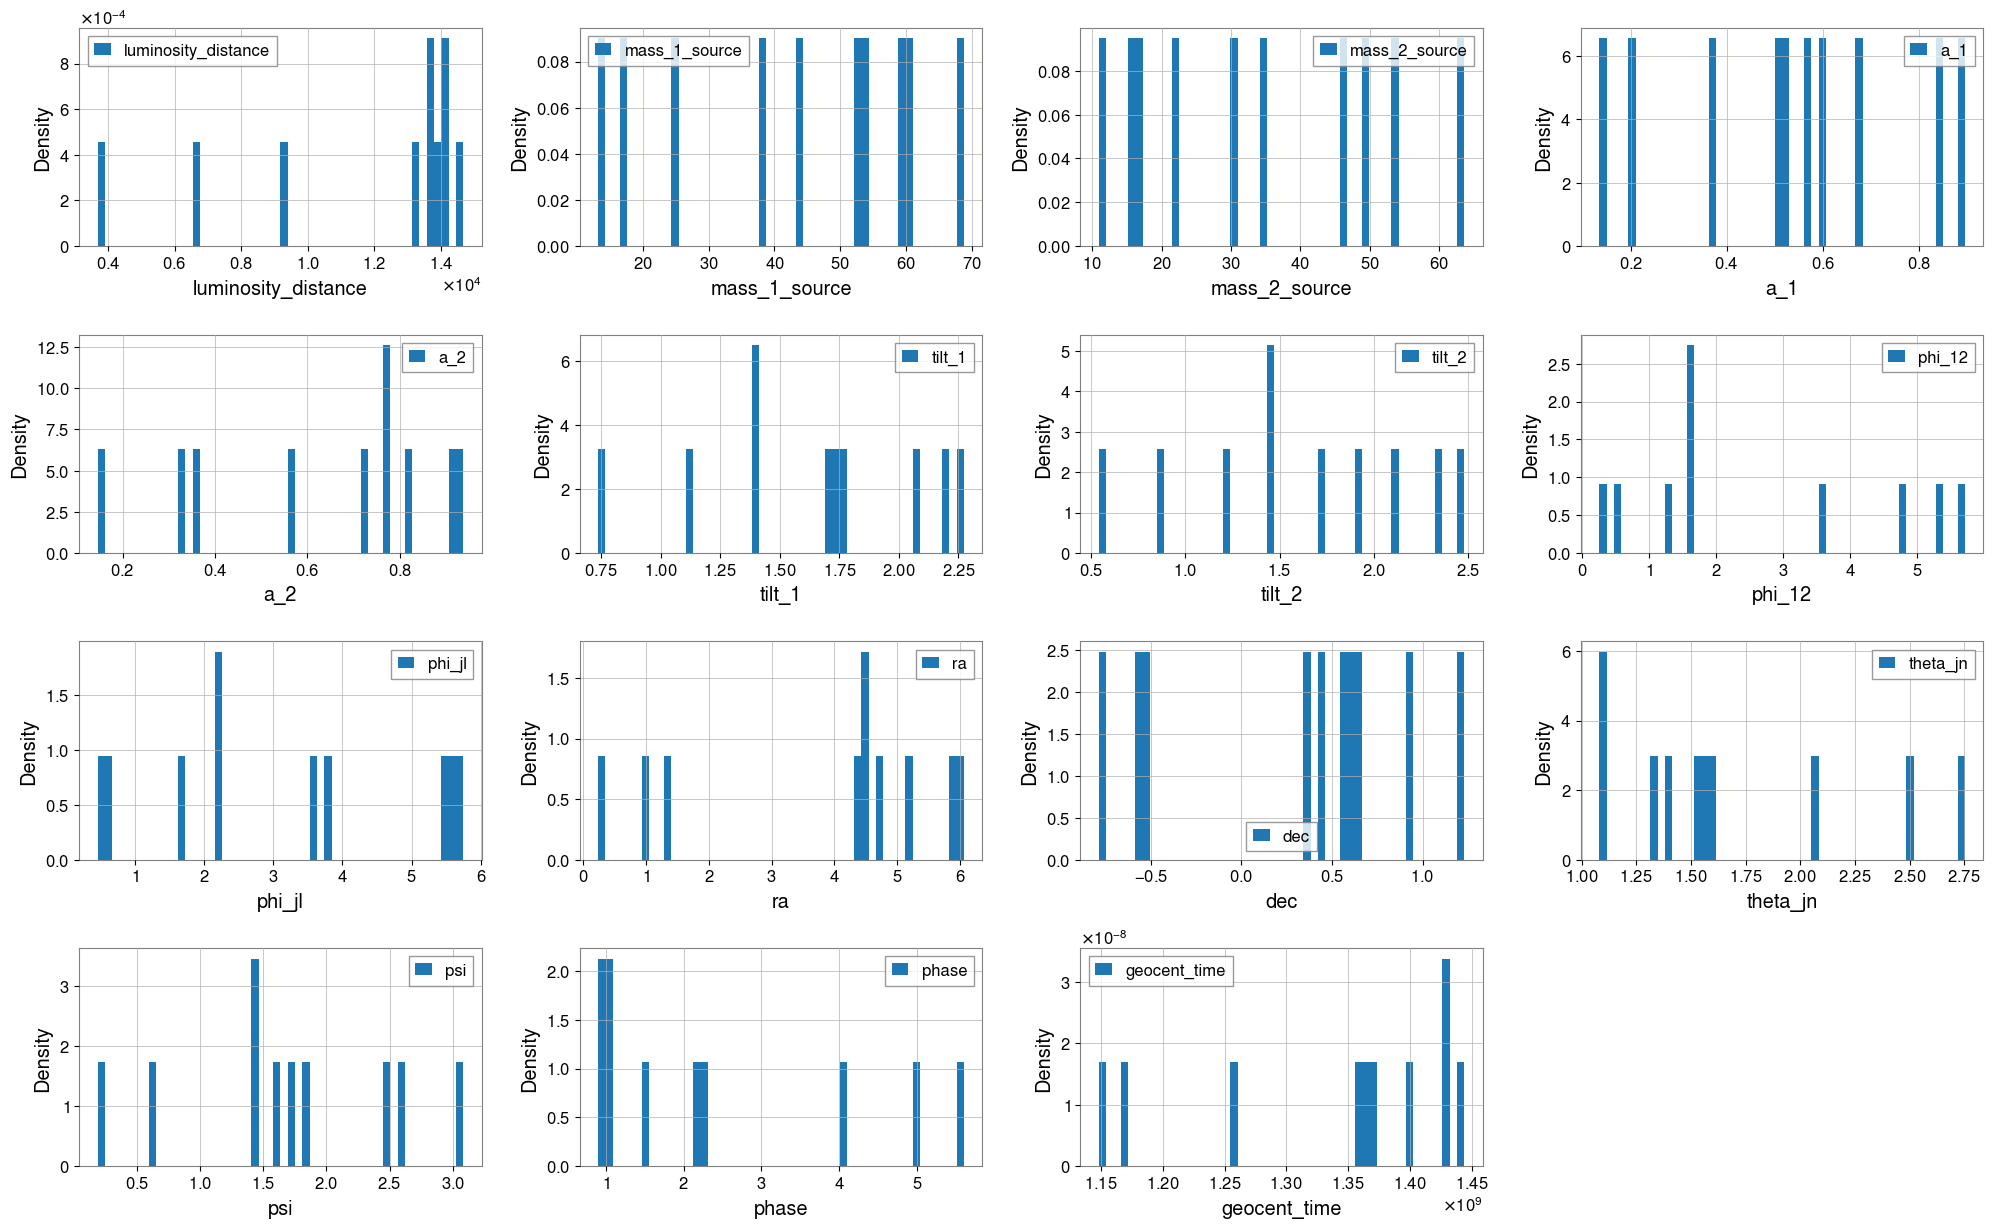

In [5]:
bilby.core.utils.random.seed(n)


# sampling from priors
def prior_GW():
    priors = bilby.core.prior.PriorDict()
    priors['luminosity_distance']=bilby.gw.prior.UniformComovingVolume(
        name="luminosity_distance", minimum=d_L_min, maximum=d_L_max, latex_label="r'$d_L$ (Mpc)'")
    priors['mass_1_source']= bilby.core.prior.Uniform(m_min, m_max, 'mass_1_source')
    priors['mass_2_source']= bilby.core.prior.Uniform(m_min, m_max, 'mass_2_source')
    priors['a_1']= bilby.core.prior.Uniform(0, 0.99, 'a_1')
    priors['a_2']= bilby.core.prior.Uniform(0, 0.99, 'a_2')
    priors['tilt_1']= bilby.core.prior.Sine(name='tilt_1')
    priors['tilt_2']= bilby.core.prior.Sine(name='tilt_2')
    priors['phi_12']= bilby.core.prior.Uniform(0, 2 * np.pi, 'phi_12', boundary='periodic')
    priors['phi_jl']= bilby.core.prior.Uniform(0, 2 * np.pi, 'phi_jl', boundary='periodic')
    priors['ra']= bilby.core.prior.Uniform(0, 2 * np.pi, 'ra', boundary='periodic')
    priors['dec']= bilby.core.prior.Cosine(name='dec')
    priors['theta_jn']= bilby.core.prior.Sine(name='theta_jn')
    priors['psi']= bilby.core.prior.Uniform(0, np.pi, 'psi', boundary='periodic')
    priors['phase']= bilby.core.prior.Uniform(0, 2 * np.pi, 'phase', boundary='periodic')
    priors['geocent_time']= bilby.core.prior.Uniform(time_start, time_end, 'geocent_time')

    return priors

priors = prior_GW()
samples = priors.sample(n_samples)
print(samples.keys())

fig, axes = plt.subplots(5, 4, figsize=(20, 15))
axes = axes.flatten()
for i, key in enumerate(samples.keys()):
    ax = axes[i]
    ax.hist(samples[key], bins=50, density=True, label=key)
    ax.set_xlabel(key)
    ax.set_ylabel('Density')
    ax.legend()
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
# plt.savefig('source_samples.pdf')


# 保存数据
source_params = pd.DataFrame(samples)
source_params.to_csv('source_samples.csv', index=False)
source_params

# 2. GW data

## ALL unlensed GW data
<!-- ### 直接运行此单元格，利用1中得到的参数，生成所有GW事件非透镜化（共n_samples组）的时域数据(whitened)。保存t,data,SNR至文件 All_unlensed_events_data.npz -->

### 直接运行此单元格，利用1中得到的参数，生成所有GW事件非透镜化（共n_samples组）的时域数据(whitened)

### 保存data_strain, time_array, optimal_SNR至对应的.npy文件 

In [ ]:
bilby.core.utils.random.seed(n + 1)

N = int(sampling_frequency * duration)

waveform_arguments = dict(
    waveform_approximant='IMRPhenomXPHM',
    reference_frequency=10.,
    minimum_frequency=minimum_frequency
)

waveform_generator = bilby.gw.WaveformGenerator(
    duration=duration,
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments
)

source_params = pd.read_csv('source_samples.csv')
n_events = len(source_params)


ifos = bilby.gw.detector.InterferometerList(["H1", "L1"])
ifo_names = [ifo.name for ifo in ifos]
n_ifos = len(ifos)



# 输出文件
tmp_data = os.path.join(tmp_dir, "unlensed_data_strain.tmp.npy")
tmp_h    = os.path.join(tmp_dir, "unlensed_h_strain.tmp.npy")
tmp_t    = os.path.join(tmp_dir, "unlensed_time_array.tmp.npy")
tmp_snr_single = os.path.join(tmp_dir, "unlensed_optimal_SNR_single.tmp.npy")
tmp_snr_net    = os.path.join(tmp_dir, "unlensed_optimal_SNR_network.tmp.npy")

for p in [tmp_data, tmp_h, tmp_t, tmp_snr_single, tmp_snr_net]:
    if os.path.exists(p):
        os.remove(p)

# shape(n_events, n_ifos, N)
data_whiten_mm = np.lib.format.open_memmap(
    tmp_data, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N)
)
h_whiten_mm = np.lib.format.open_memmap(
    tmp_h, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N)
)
t_mm = np.lib.format.open_memmap(
    tmp_t, mode="w+", dtype=np.float64, shape=(n_events, n_ifos, N)
)

# 每个探测器各自的optimal SNR
snr_single_mm = np.lib.format.open_memmap(
    tmp_snr_single, mode="w+", dtype=np.float64, shape=(n_events, n_ifos)
)

# 总SNR
snr_net_mm = np.lib.format.open_memmap(
    tmp_snr_net, mode="w+", dtype=np.float64, shape=(n_events,)
)


for i in range(n_events):

    injection_parameters = source_params.iloc[i].to_dict()

    r = 1500


    # 先生成一次频域波形，后面每个探测器共用
    fd_waveform = waveform_generator.frequency_domain_strain(injection_parameters)

    snr_sq_network = 0.0

    for j, ifo in enumerate(ifos):

        # 为当前探测器生成噪声
        ifo.set_strain_data_from_power_spectral_density(
            sampling_frequency=sampling_frequency,
            duration=duration,
            start_time=injection_parameters["geocent_time"] - (N-r) / sampling_frequency)
        
        n_t = ifo.strain_data.time_domain_strain.copy()
        t_array = ifo.strain_data.time_array.copy()

        n_f_white = ifo.whitened_frequency_domain_strain
        n_t_white = np.fft.irfft(n_f_white, n=N)

        # 当前探测器响应
        response = ifo.get_detector_response(fd_waveform, injection_parameters)
        snr_squared = np.real(ifo.optimal_snr_squared(response))
        snr = np.sqrt(np.abs(snr_squared))

        snr_single_mm[i, j] = snr
        snr_sq_network += np.abs(snr_squared)

        # 注入信号
        ifo.inject_signal(
            waveform_generator=waveform_generator,
            parameters=injection_parameters
        )

        d_t = ifo.strain_data.time_domain_strain.copy()

        d_f_white = ifo.whitened_frequency_domain_strain
        d_t_white = np.fft.irfft(d_f_white, n=N)

        h_t = d_t - n_t
        h_t_white = d_t_white - n_t_white



        # 信号h(t)在峰值后0.05秒处进行切除，并使用Hanning窗平滑过渡到零
        peak_index = np.argmax(np.abs(h_t_white))

        cut_index = peak_index + int(0.05 * sampling_frequency)
        cut_index = min(cut_index, N)

        h_t_white_new = h_t_white.copy()

        fade_len = N - cut_index
        if fade_len > 0:
            hann_full = np.hanning(2 * fade_len)
            fade_window = hann_full[fade_len:]
            h_t_white_new[cut_index:] *= fade_window

        d_t_white_new = h_t_white_new + n_t_white



        # 保存
        t_mm[i, j, :] = t_array
        data_whiten_mm[i, j, :] = d_t_white_new
        h_whiten_mm[i, j, :] = h_t_white_new

    # 保存网络SNR
    snr_net_mm[i] = np.sqrt(snr_sq_network)

# flush
data_whiten_mm.flush()
h_whiten_mm.flush()
t_mm.flush()
snr_single_mm.flush()
snr_net_mm.flush()

# 最终文件名
final_data = "unlensed_data_strain.npy"
final_h    = "unlensed_h_strain.npy"
final_t    = "unlensed_time_array.npy"
final_snr_single = "unlensed_optimal_SNR_single.npy"
final_snr_net    = "unlensed_optimal_SNR_network.npy"

for p in [final_data, final_h, final_t, final_snr_single, final_snr_net]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(tmp_data, final_data)
shutil.move(tmp_h, final_h)
shutil.move(tmp_t, final_t)
shutil.move(tmp_snr_single, final_snr_single)
shutil.move(tmp_snr_net, final_snr_net)

22:19 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
22:19 bilby INFO    : Injected signal in H1:
22:19 bilby INFO    :   optimal SNR = 1.51
22:19 bilby INFO    :   matched filter SNR = 2.60+1.13j
22:19 bilby INFO    :   luminosity_distance = 14672.565960214744
22:19 bilby INFO    :   mass_1_source = 59.36479244544535
22:19 bilby INFO    :   mass_2_source = 49.34752516418322
22:19 bilby INFO    :   a_1 = 0.3664145093382993
22:19 bilby INFO    :   a_2 = 0.777081584728041
22:19 bilby INFO    :   tilt_1 = 2.068997442115043
22:19 bilby INFO    :   tilt_2 = 1.7109975127811214
22:19 bilby INFO    :   phi_12 = 0.2560400007155373
22:19 bilby INFO    :   phi_jl = 1.6370243493432126
22:19 bilby INFO    :   ra = 0.2363263781054137
22:19 bilby INFO    :   dec = 0.6449549248689471
22:19 bilby INFO    :   th

'unlensed_optimal_SNR_network.npy'

In [ ]:
bilby.core.utils.random.seed(n+1)

N = sampling_frequency*duration

waveform_arguments = dict(waveform_approximant='IMRPhenomXPHM',
                          reference_frequency=10., minimum_frequency=minimum_frequency)

# unlensed_waveform 
waveform_generator=bilby.gw.WaveformGenerator(
    duration=duration, 
    sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_black_hole,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments)


source_params = pd.read_csv('source_samples.csv')
n_events = len(source_params)


tmp_data = os.path.join(tmp_dir, "unlensed_data_strain.tmp.npy")
tmp_h    = os.path.join(tmp_dir, "unlensed_h_strain.tmp.npy")
tmp_t    = os.path.join(tmp_dir, "unlensed_time_array.tmp.npy")
tmp_snr  = os.path.join(tmp_dir, "unlensed_optimal_SNR.tmp.npy")

for p in [tmp_data, tmp_h, tmp_t, tmp_snr]:
    if os.path.exists(p):
        os.remove(p)

data_whiten_mm = np.lib.format.open_memmap(
    tmp_data, mode="w+", dtype=np.float64, shape=(n_events, N))
h_whiten_mm = np.lib.format.open_memmap(
    tmp_h, mode="w+", dtype=np.float64, shape=(n_events, N))
t_mm = np.lib.format.open_memmap(
    tmp_t, mode="w+", dtype=np.float64, shape=(n_events, N))
snr_mm = np.lib.format.open_memmap(
    tmp_snr, mode="w+", dtype=np.float64, shape=(n_events,))



ET_0 = bilby.gw.detector.InterferometerList(['ET'])[0]  # 只使用ET的一个探测器

# 读取每一组参数，计算对应的引力波信号
for i in range(len(source_params)):

    # 取出一组参数
    injection_parameters = source_params.iloc[i].to_dict()  # 将第 i 行转换为字典

    r=1500

    fd_waveform = waveform_generator.frequency_domain_strain(injection_parameters)

    ET_0.set_strain_data_from_power_spectral_density(
        sampling_frequency=sampling_frequency,
        duration=duration,  
        start_time=injection_parameters["geocent_time"] - (N-r) / sampling_frequency)

    n_t=ET_0.strain_data.time_domain_strain
    t_array=ET_0.strain_data.time_array

    n_f_white = ET_0.whitened_frequency_domain_strain
    n_t_white = np.fft.irfft(n_f_white, n=N)

    

    response = ET_0.get_detector_response(fd_waveform, injection_parameters)
    snr_squared = ET_0.optimal_snr_squared(response)
    snr = np.abs(np.sqrt(snr_squared))

    ET_0.inject_signal(waveform_generator=waveform_generator, 
                        parameters=injection_parameters)
    
    d_t=ET_0.strain_data.time_domain_strain

    d_f_white = ET_0.whitened_frequency_domain_strain
    d_t_white = np.fft.irfft(d_f_white, n=N)

    h_t=d_t-n_t
    h_t_white=d_t_white-n_t_white

    # 信号h(t)在峰值后0.05秒处进行切除，并使用Hanning窗平滑过渡到零
    peak_index = np.argmax(np.abs(h_t_white))

    cut_index = peak_index + int(0.05 * sampling_frequency)
    cut_index = min(cut_index, N)

    h_t_white_new = h_t_white.copy()

    fade_len = N - cut_index
    if fade_len > 0:
        hann_full = np.hanning(2 * fade_len)
        fade_window = hann_full[fade_len:]
        h_t_white_new[cut_index:] *= fade_window

    d_t_white_new = h_t_white_new + n_t_white
  

    t_mm[i, :] = t_array
    snr_mm[i] = snr
    data_whiten_mm[i, :] = d_t_white_new
    h_whiten_mm[i, :] = h_t_white_new

data_whiten_mm.flush()
h_whiten_mm.flush()
t_mm.flush()
snr_mm.flush()

final_data = "unlensed_data_strain.npy"
final_h   = "unlensed_h_strain.npy"
final_t   = "unlensed_time_array.npy"
final_snr = "unlensed_optimal_SNR.npy"

for p in [final_data, final_h, final_t, final_snr]:
    if os.path.exists(p):
        os.remove(p)

shutil.move(tmp_data, final_data)
shutil.move(tmp_h, final_h)
shutil.move(tmp_t, final_t)
shutil.move(tmp_snr, final_snr)

20:18 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters
20:18 bilby INFO    : Injected signal in ET1:
20:18 bilby INFO    :   optimal SNR = 25.10
20:18 bilby INFO    :   matched filter SNR = 25.70+0.22j
20:18 bilby INFO    :   luminosity_distance = 14672.565960214744
20:18 bilby INFO    :   mass_1_source = 54.33538281768277
20:18 bilby INFO    :   mass_2_source = 58.03487255129759
20:18 bilby INFO    :   a_1 = 0.8842683251408817
20:18 bilby INFO    :   a_2 = 0.5487020007425643
20:18 bilby INFO    :   tilt_1 = 2.4304945373287024
20:18 bilby INFO    :   tilt_2 = 0.9289115747087278
20:18 bilby INFO    :   phi_12 = 0.7695154122514597
20:18 bilby INFO    :   phi_jl = 1.5571568220325538
20:18 bilby INFO    :   ra = 1.6888953910723437
20:18 bilby INFO    :   dec = -0.2403827554715932
20:18 bilby INFO    

'unlensed_optimal_SNR.npy'